# 乳腺癌

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from sklearn.metrics import adjusted_rand_score

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / "SpaDiff_improved").is_dir()),
    cwd,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import SpaDiff_improved as sd
from SpaDiff_improved.spatial import Neiber
from SpaDiff_improved.utils import (
    adjust_louvain_resolution, cal_purity, set_seed,
)

## 参数、设备与路径

In [2]:
SEED = 42
SLICE_ORDER = ["H_1", "H_2", "H_3"]
REFERENCE_BATCH = "H_1"
TRUTH_KEY = "pathologist"
N_CLUSTERS = 7
N_COMPONENTS = 50
K_INTRA = 5
K_INTER = 2
FAST_DEV_RUN = False

# loss = K1 * original DEC-KL + K2 * diffusion DSM
K1 = 1.0
K2 = 0.0
DEC_ONLY = K1 > 0.0 and K2 == 0.0

DATA_ROOT = Path("E:/gxy_2/final/0_data/case3/")
print("DATA_ROOT =", DATA_ROOT)

set_seed(SEED)
torch.backends.cudnn.deterministic = True
device = torch.device("cpu") if DEC_ONLY else torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)
print("device =", device)
print(f"loss = {K1} * original_DEC + {K2} * diffusion_DSM")


DATA_ROOT = E:\gxy_2\final\0_data\case3
device = cpu
loss = 1.0 * original_DEC + 0.0 * diffusion_DSM


## 读取三个乳腺癌切片并按共同基因拼接

In [3]:
samples = {}
for sample in SLICE_ORDER:
    current = sc.read_h5ad(DATA_ROOT / f"{sample}.h5ad")
    current.var_names_make_unique()

    sc.pp.normalize_total(current, target_sum=1e4)
    sc.pp.log1p(current)
    # sc.pp.scale(current, max_value=10)

    samples[sample] = current

adata = sc.concat(
    samples, join="inner", label="batch_name", index_unique="-"
)
adata.obs["batch_name"] = pd.Categorical(
    adata.obs["batch_name"], categories=SLICE_ORDER, ordered=True
)
adata.layers["counts"] = adata.X.copy()
print(adata)
print(adata.obs["batch_name"].value_counts())
if TRUTH_KEY not in adata.obs:
    print(f"未找到 {TRUTH_KEY!r}，后续将跳过 purity 与 ARI。")

AnnData object with n_obs × n_vars = 1726 × 13729
    obs: 'cluster', 'pathologist', 'batch_name'
    obsm: 'spatial'
    layers: 'counts'
batch_name
H_1    613
H_2    603
H_3    510
Name: count, dtype: int64


## HVG、 PCA 

In [4]:
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer="counts",n_top_genes=min(3000, adata.n_vars), batch_key="batch_name",)
adata = adata[:, adata.var["highly_variable"]].copy()

latent_dim = min(N_COMPONENTS, adata.n_obs - 1, adata.n_vars - 1)
if latent_dim < 2:
    raise ValueError("可用 spot 或基因过少，无法构建 PCA 表示")
sc.tl.pca(adata, n_comps=latent_dim, svd_solver="arpack")
pca_array = np.ascontiguousarray(adata.obsm["X_pca"], dtype=np.float32)
features = torch.from_numpy(pca_array).to(device)
print("PCA feature shape =", tuple(features.shape))

PCA feature shape = (1726, 50)


## 构建单纯复形

In [5]:
_, adjacency = Neiber(
    adata, k_intra=K_INTRA, k_inter=K_INTER, slice_order=SLICE_ORDER
)
adjacency = adjacency.maximum(adjacency.T)
operators = sd.to_torch_operators(
    sd.build_simplicial_operators(adjacency, max_order=2), device=device
)
batch_codes = adata.obs["batch_name"].cat.codes.to_numpy()
if np.any(batch_codes < 0):
    raise ValueError("batch_name 中存在未定义类别")
batch_ids = torch.as_tensor(batch_codes, dtype=torch.long, device=device)
modality_ids = torch.zeros(adata.n_obs, dtype=torch.long, device=device)
print("edge nnz =", operators[1]._nnz())
print("triangle nnz =", operators[2]._nnz())

edge nnz = 14614
triangle nnz = 12518


### 训练条件 VP-SDE

In [6]:
config = sd.SpaDiffConfig(
    data_dim=latent_dim,
    condition_input_dim=latent_dim,
    hidden_dim=128,
    topology_hidden_dim=64,
    topology_dim=64,
    score_depth=4,
    dropout=0.2,
    topology_projection_dropout=0.1 if K1 > 0.0 else None,
    simplex_orders=(1, 2),
    propagation_steps=5,
    propagation_alpha=0.4,
    num_batches=len(SLICE_ORDER),
    num_modalities=1,
    num_scales=50 if FAST_DEV_RUN else 1000,
    k1=K1,
    k2=K2,
    num_clusters=N_CLUSTERS,
    dec_alpha=1.0,
    dec_update_interval=10,
    dec_init_method="mclust",
    dec_tolerance=1e-3,
    random_seed=SEED,
)
model = sd.SpaDiff(config).to(device)
training_epochs = 5 if FAST_DEV_RUN else (200 if DEC_ONLY else 500)
training = sd.train_spadiff(
    model,
    target_features=features,
    operators=operators,
    batch_ids=batch_ids,
    modality_ids=modality_ids,
    condition_features=features,
    epochs=training_epochs,
    learning_rate=1e-3,
    weight_decay=1e-4,
    ema_decay=None if DEC_ONLY else 0.999,
    verbose_every=1 if FAST_DEV_RUN or DEC_ONLY else 25,
)
print("best total loss =", training.best_loss)
print("last original DEC loss =", training.original_losses[-1])
print("last diffusion loss =", training.diffusion_losses[-1])


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 5.4.10
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
Epoch 0001/200 | total=0.092430 | original=0.092430 | diffusion=0.000000
Epoch 0002/200 | total=0.083929 | original=0.083929 | diffusion=0.000000
Epoch 0003/200 | total=0.077470 | original=0.077470 | diffusion=0.000000
Epoch 0004/200 | total=0.074340 | original=0.074340 | diffusion=0.000000
Epoch 0005/200 | total=0.070541 | original=0.070541 | diffusion=0.000000
Epoch 0006/200 | total=0.067639 | original=0.067639 | diffusion=0.000000
Epoch 0007/200 | total=0.066531 | original=0.066531 | diffusion=0.000000
Epoch 0008/200 | total=0.063575 | original=0.063575 | diffusion=0.000000
Epoch 0009/200 | total=0.062272 | original=0.062272 | diffusion=0.000000
Epoch 0010/200 | total=0.058876 | original=0.058876 | diffusion=0.000000
Epoch 0011/200 | total=0.149350 | original=0.149350 | diffusion=0.000000
Epoch 0012/200 | total=0.142354 | original=0.142354 | diffusion=0.000000
Epoch 0013/200 | total=0.136646 

### EMA 权重下的条件去噪

In [7]:
if DEC_ONLY:
    dec_labels, dec_prob, embedding = model.original_predict(features, operators)
    corrected = embedding
else:
    reference_code = SLICE_ORDER.index(REFERENCE_BATCH)
    reference_batch_ids = torch.full_like(batch_ids, reference_code)
    if training.ema is not None:
        training.ema.store(model.parameters())
        training.ema.copy_to(model.parameters())
    try:
        corrected = model.harmonize(
            observed_features=features,
            operators=operators,
            reference_batch_ids=reference_batch_ids,
            modality_ids=modality_ids,
            condition_features=features,
            strength=0.30,
            sampler="ode",
            guidance_scale=1.1,
            ode_steps=20 if FAST_DEV_RUN else 250,
        )
    finally:
        if training.ema is not None:
            training.ema.restore(model.parameters())

adata.obsm["X_spadiff"] = corrected.cpu().numpy()
print("SpaDiff embedding shape =", adata.obsm["X_spadiff"].shape)


SpaDiff embedding shape = (1726, 64)


## Louvain聚类空间域

In [8]:
adata = adjust_louvain_resolution(
    adata,
    target_n_clusters=N_CLUSTERS,
    use_rep="X_spadiff",
    key_added="louvain",
    n_neighbors=15,
    random_state=SEED,
    resolution_bounds=(0.01, 5.0),
    tolerance=0,
    max_iterations=25,
    verbose=True,
)
search = adata.uns["louvain_resolution_search"]
print("selected resolution =", search["selected_resolution"])
print("selected clusters =", search["selected_n_clusters"])

Adjusting Louvain toward 7 clusters.
Searching resolution in [0.01, 5] for 7 clusters...
  resolution=0.01 -> 1 clusters (target=7)
  resolution=5 -> 39 clusters (target=7)
  resolution=2.505 -> 21 clusters (target=7)
  resolution=1.2575 -> 14 clusters (target=7)
  resolution=0.63375 -> 8 clusters (target=7)
  resolution=0.321875 -> 7 clusters (target=7)
Selected resolution=0.321875: 7 clusters (target reached).
selected resolution = 0.32187499999999997
selected clusters = 7


In [9]:
def evaluate_partition(obs, truth_key=TRUTH_KEY, pred_key="louvain"):
    valid = obs[[truth_key, pred_key]].dropna()
    truth_codes = pd.Categorical(valid[truth_key]).codes
    pred_codes = pd.Categorical(valid[pred_key]).codes
    purity = cal_purity(truth_codes, pred_codes)
    ari = adjusted_rand_score(valid[truth_key].astype(str), valid[pred_key].astype(str))
    return purity, ari, len(valid)

if TRUTH_KEY in adata.obs:
    for sample in SLICE_ORDER:
        subset_obs = adata.obs.loc[adata.obs["batch_name"] == sample]
        purity, ari, n_valid = evaluate_partition(subset_obs)
        print(f"{sample}: n={n_valid}, purity={purity:.3f}, ARI={ari:.3f}")
    purity, ari, n_valid = evaluate_partition(adata.obs)
    print(f"all slices: n={n_valid}, purity={purity:.3f}, ARI={ari:.3f}")
else:
    print("没有病理标签，跳过外部聚类指标。")

H_1: n=613, purity=0.780, ARI=0.260
H_2: n=603, purity=0.763, ARI=0.249
H_3: n=510, purity=0.769, ARI=0.303
all slices: n=1726, purity=0.771, ARI=0.263


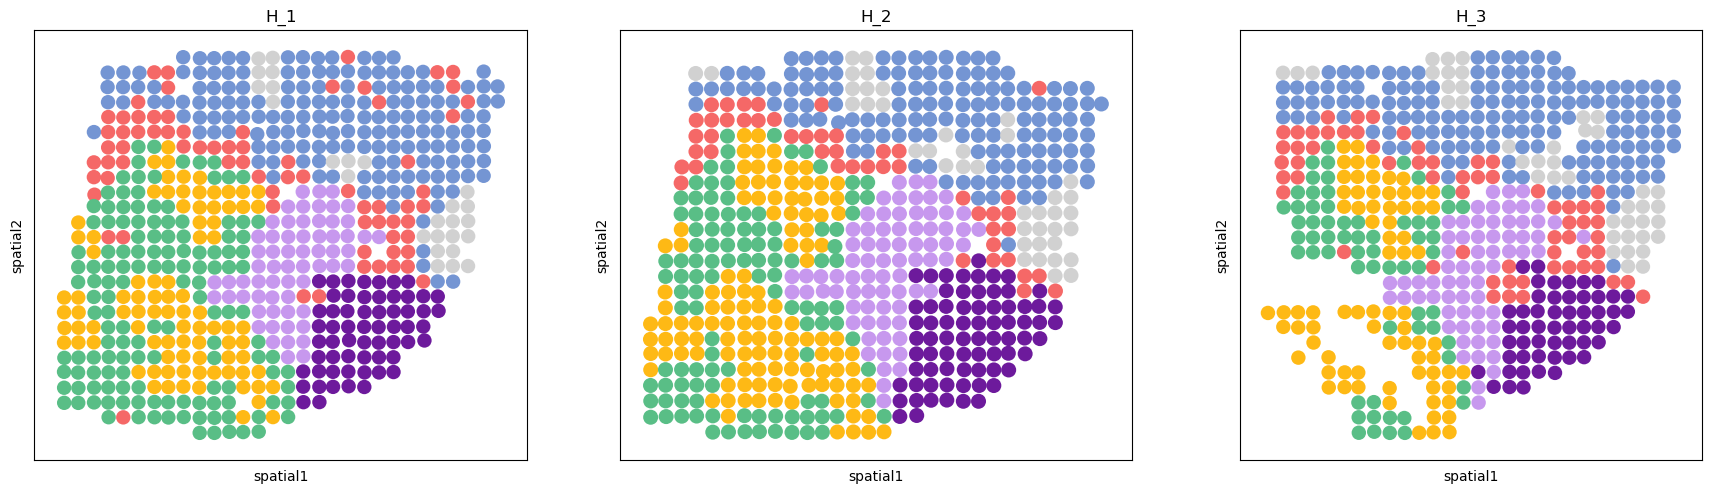

In [10]:
plot_color = ["#7495D3", "#59BE86", "#FEB915", "#C798EE", "#6D1A9C", "#F56867", "#D1D1D1"]
fig, axes = plt.subplots(1, len(SLICE_ORDER), figsize=(18, 5))
for axis, sample in zip(np.atleast_1d(axes), SLICE_ORDER):
    subset = adata[adata.obs["batch_name"] == sample].copy()
    sc.pl.spatial(
        subset, color="louvain", ax=axis, show=False, spot_size=280,
        palette=plot_color, legend_loc=None, title=sample,
    )
plt.tight_layout()
plt.show()

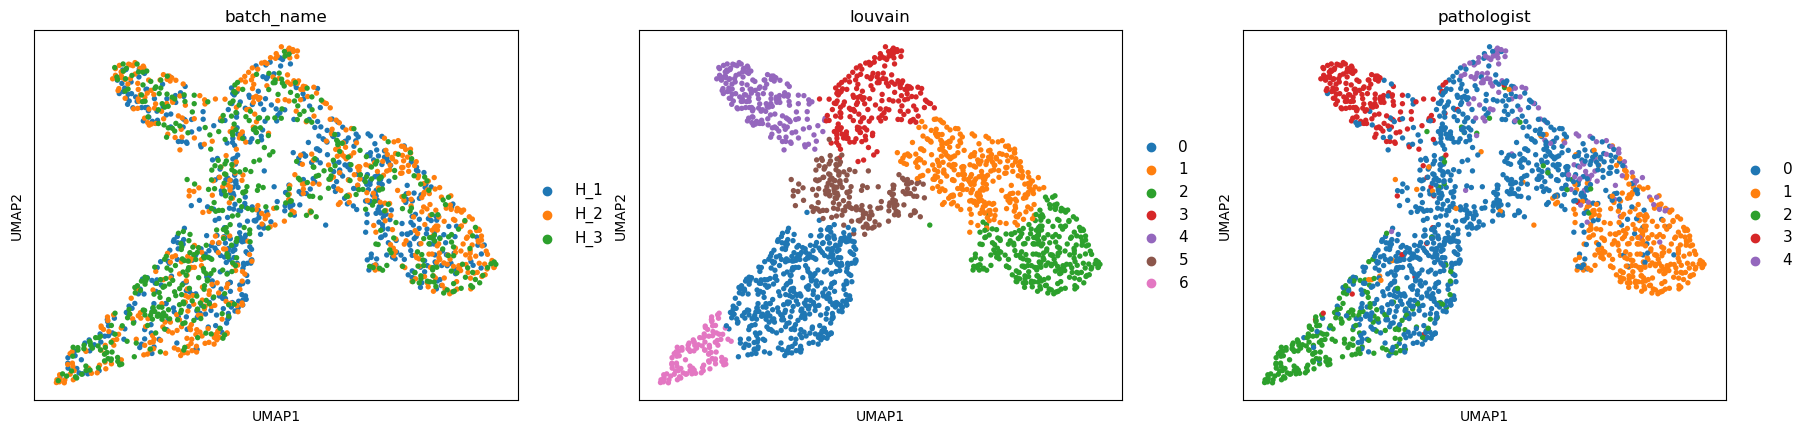

In [11]:

sc.tl.umap(adata, random_state=SEED)
colors = ["batch_name", "louvain"]
if TRUTH_KEY in adata.obs:
    colors.append(TRUTH_KEY)
sc.pl.umap(
    adata, color=colors, size=60,
    legend_fontsize=11, legend_fontoutline=2,
)